In [1]:
import torch
import torch.nn as nn
import numpy as np
from DDBSCAN import Raster_DBSCAN
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
from Models import *
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
from ModelSocial import LaneSocialLSTM
from Dataset import MemoryMappedSocialLSTMDataset
import h5py

# from TrainSocialLSTM import extract_trajectories,prepare_training_data
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LaneSocialLSTM(
    hidden_size=128,
    social_size=32,
    neighborhood_size=16,
    num_layers=1,
    input_frames=10,
    output_frames=1,
    lane_cells=200,
    dropout=0.2,
    device=device
).to(device)
model_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\models\social_lstm\train_10\best_model.pth'
model.load_state_dict(torch.load(model_path,weights_only=False)['model_state_dict'])

<All keys matched successfully>

In [4]:
val_h5_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset_10-1\val\social_lstm_data.h5'
val_dataset = MemoryMappedSocialLSTMDataset(
        h5_path=val_h5_path,
        input_frames=10,
        output_frames=1
    )
val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        # num_workers=4,
        # pin_memory=True
    )

Loading preprocessed data from D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset_10-1\val\social_lstm_data.h5_preprocessed_i10_o1_s2.0.npz...
Loaded 5978 valid trajectories


In [5]:
for batch in val_loader:
    input_positions, input_context, target_positions, output_distributions, output_masks = batch
    input_positions = input_positions.to(device)
    input_context = input_context.to(device)
    target_positions = target_positions.to(device)
    output_distributions = output_distributions.to(device)
    print(input_positions.shape, input_context.shape, target_positions.shape, output_distributions.shape, output_masks.shape)
    break  # Remove this to process all batches

torch.Size([32, 10]) torch.Size([32, 10, 200]) torch.Size([32, 1]) torch.Size([32, 1, 200]) torch.Size([32, 1])


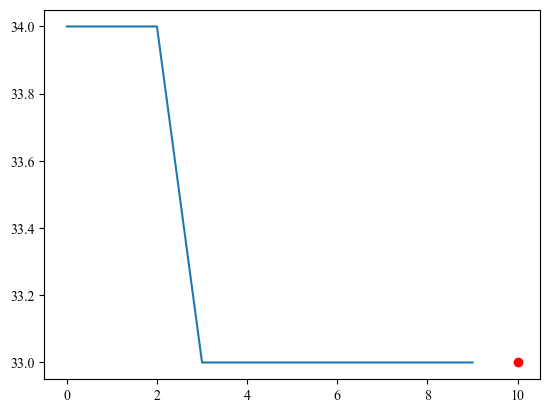

In [15]:
with torch.no_grad():
    model.eval()
    idx = 6
    lane_cells = 200
    pred_distributions = model(input_positions, input_context)
    input_pos = input_positions[idx].cpu().numpy()
    input_ctx = input_context[idx].cpu().numpy()
    pred_dist = pred_distributions[idx].cpu().numpy()

    # Total number of frames
    input_frames = input_pos.shape[0]
    output_frames = pred_dist.shape[0]
    total_frames = input_frames + output_frames
    plt.plot(input_positions[idx].cpu().numpy())
    plt.scatter(input_positions[idx].shape[0], pred_dist.flatten().argmax(axis=0), color='red', label='Predicted Position')
    plt.show()


    

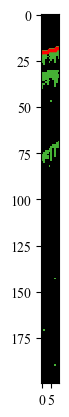

In [14]:
plt.imshow(input_context[0].cpu().numpy().T, cmap=colormap, interpolation='none')
# plot the input positions
plt.scatter(np.arange(10),input_positions[0].cpu().numpy(), color='red', marker='o', label='Input Positions', s = 3)
plt.show()